# 🛒 E-commerce Funnel Analysis
**Goal:** Identify where users drop off in the purchase funnel and quantify the business impact of improving conversion.

**Dataset:** 885,129 raw e-commerce events (views, carts, purchases) with product price data.  
**Source:** REES46 E-commerce Dataset (Kaggle)

---

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load full dataset
df_full = pd.read_csv('../data/raw and cleaned data/events.csv')
print(f"Full dataset: {df_full.shape[0]:,} rows, {df_full.shape[1]} columns")
df_full.head()

Full dataset: 885,129 rows, 9 columns


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06 UTC,view,1996170,2144415922528452715,electronics.telephone,NaN,31.90,1515915625519388267,LJuJVLEjPT
1,2020-09-24 11:57:26 UTC,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY
2,2020-09-24 11:57:27 UTC,view,215454,2144415927158964449,NaN,NaN,9.81,1515915625513238515,4TMArHtXQy
3,2020-09-24 11:57:33 UTC,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08
4,2020-09-24 11:57:36 UTC,view,3658723,2144415921169498184,NaN,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ


## 2. Data Cleaning & Validation

In [2]:
# Work on a reproducible 20K sample for speed
df = df_full.sample(20000, random_state=42).copy()

# Fix types
df['event_time'] = pd.to_datetime(df['event_time'], utc=True)

# Fill missing category
df['category_code'] = df['category_code'].fillna('Unknown')

# Remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")

# Validate event types
valid_events = ['view', 'cart', 'purchase']
invalid = df[~df['event_type'].isin(valid_events)]
print(f"Invalid event types: {len(invalid)}")

# Validate prices (no negatives)
print(f"Negative prices: {(df['price'] < 0).sum()}")
print(f"Missing prices: {df['price'].isnull().sum()}")

# Feature engineering
df['hour'] = df['event_time'].dt.hour
df['day'] = pd.Categorical(
    df['event_time'].dt.day_name(),
    categories=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'],
    ordered=True
)

print(f"\nCleaned dataset: {df.shape[0]:,} rows")
df.head()

Removed 1 duplicate rows
Invalid event types: 0
Negative prices: 0
Missing prices: 0

Cleaned dataset: 19,999 rows


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,hour,day
192708,2020-11-01 14:36:11+00:00,view,4156279,2144415922587172973,electronics.telephone,NaN,12.22,1515915625533221908,krDzDYA6J0,14,Sunday
43645,2020-10-04 13:48:49+00:00,view,1283611,2144415952391898012,appliances.environment.vacuum,bort,170.00,1515915625469806973,C8YU0DjTP8,13,Sunday
148601,2020-10-25 06:27:19+00:00,view,3791351,2144415926966026460,computers.components.cpu,amd,204.29,1515915625530210252,GFm0pEaVjK,6,Sunday
592601,2021-01-12 08:26:56+00:00,view,3957221,2144415922427789416,computers.components.videocards,asus,451.32,1515915625592186998,E57Elq8HVE,8,Tuesday
355859,2020-11-26 12:29:34+00:00,view,227145,2144415921085612102,Unknown,NaN,13.00,1515915625544205939,jvqzdCSUUw,12,Thursday


In [3]:
# Event type distribution
print("Event type breakdown:")
print(df['event_type'].value_counts())
print()

# Price distribution by event type
print("Price statistics by event type:")
df.groupby('event_type')['price'].describe().round(2)

Event type breakdown:
event_type
view        17861
cart         1305
purchase      833
Name: count, dtype: int64

Price statistics by event type:


,count,mean,std,min,25%,50%,75%,max
event_type,,,,,,,,
cart,1305.0,153.32,166.61,0.90,28.71,80.35,218.98,1232.63
purchase,833.0,135.28,150.10,0.90,26.46,72.19,204.29,839.75
view,17861.0,143.70,219.14,0.37,26.51,65.40,187.29,5149.38


**Note:** The `price` column is populated for all event types (view, cart, purchase). For revenue calculations, we use only `purchase` events since those represent actual completed transactions.

In [4]:
df.to_csv("../data/raw and cleaned data/funnel_clean.csv", index=False)

## 3. User-Level Funnel Metrics

We measure the funnel at the **user level** — did a given user perform each action at least once? This avoids inflating numbers from users who viewed or carted multiple times.

In [5]:
# Build user-level funnel (binary: did user perform each action?)
funnel = df.pivot_table(
    index='user_id',
    columns='event_type',
    aggfunc='size',
    fill_value=0
)

# Convert to binary flags (1 = performed, 0 = not)
funnel = funnel.map(lambda x: 1 if x > 0 else 0)

# Ensure all stages exist even if no events
for col in ['view', 'cart', 'purchase']:
    if col not in funnel.columns:
        funnel[col] = 0

total_users  = len(funnel)
viewed       = int(funnel['view'].sum())
carted       = int(funnel['cart'].sum())
purchased    = int(funnel['purchase'].sum())

view_to_cart      = carted / viewed if viewed else 0
cart_to_purchase  = purchased / carted if carted else 0
overall_conv      = purchased / viewed if viewed else 0

print(f"Total unique users : {total_users:,}")
print(f"Users who viewed   : {viewed:,}")
print(f"Users who carted   : {carted:,}")
print(f"Users who purchased: {purchased:,}")
print()
print(f"View → Cart rate   : {view_to_cart:.1%}")
print(f"Cart → Purchase rate: {cart_to_purchase:.1%}")
print(f"Overall conversion : {overall_conv:.1%}")

Total unique users : 18,471
Users who viewed   : 16,766
Users who carted   : 1,272
Users who purchased: 811

View → Cart rate   : 7.6%
Cart → Purchase rate: 63.8%
Overall conversion : 4.8%


In [6]:
# Drop-off rates
view_to_cart_dropoff     = 1 - view_to_cart
cart_to_purchase_dropoff = 1 - cart_to_purchase

print(f"Drop-off at View → Cart stage    : {view_to_cart_dropoff:.1%} of viewers do NOT add to cart")
print(f"Drop-off at Cart → Purchase stage: {cart_to_purchase_dropoff:.1%} of cart users do NOT purchase")

Drop-off at View → Cart stage    : 92.4% of viewers do NOT add to cart
Drop-off at Cart → Purchase stage: 36.2% of cart users do NOT purchase


In [7]:
# Funnel visualisation
funnel_df = pd.DataFrame({
    "Stage": ["View", "Add to Cart", "Purchase"],
    "Users": [viewed, carted, purchased]
})

fig = px.funnel(funnel_df, x="Users", y="Stage", title="User Conversion Funnel")
fig.update_layout(font=dict(size=14))
fig.show()

**Core Insight:** The biggest drop-off occurs at the **top of the funnel** — only ~7.6% of users who view products add an item to cart. However, once users do add to cart, ~63.8% complete the purchase. This tells us the problem is **product engagement**, not checkout friction.

## 4. Revenue Baseline (From Real Purchase Data)

In [8]:
# Use ONLY purchase events for revenue — these are completed transactions
purchase_events = df[df['event_type'] == 'purchase']

avg_order_value  = purchase_events['price'].mean()
total_revenue    = purchase_events['price'].sum()
median_order     = purchase_events['price'].median()

print(f"Purchase events in sample : {len(purchase_events):,}")
print(f"Average order value (AOV) : ${avg_order_value:,.2f}")
print(f"Median order value        : ${median_order:,.2f}")
print(f"Total sample revenue      : ${total_revenue:,.2f}")
print()
print("Price distribution of purchases:")
purchase_events['price'].describe().round(2)

Purchase events in sample : 833
Average order value (AOV) : $135.28
Median order value        : $72.19
Total sample revenue      : $112,686.35

Price distribution of purchases:


count    833.00
mean     135.28
std      150.10
min        0.90
25%       26.46
50%       72.19
75%      204.29
max      839.75
Name: price, dtype: float64

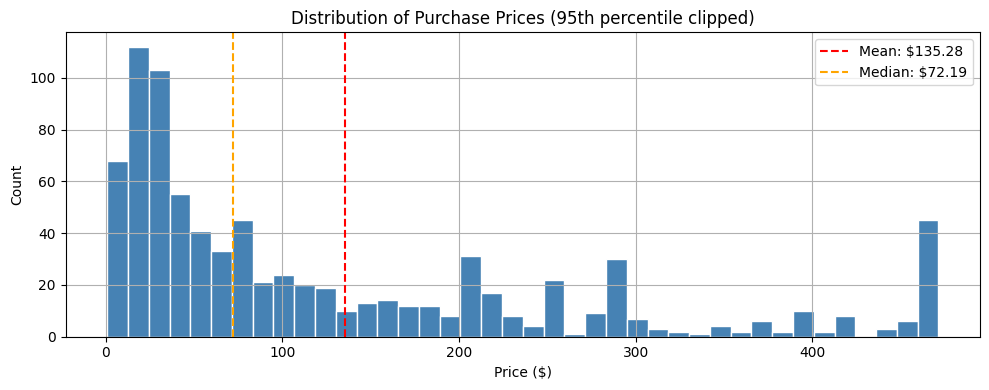

In [9]:
# Price distribution visualisation
fig, ax = plt.subplots(figsize=(10, 4))
purchase_events['price'].clip(upper=purchase_events['price'].quantile(0.95)).hist(
    bins=40, ax=ax, color='steelblue', edgecolor='white'
)
ax.axvline(avg_order_value, color='red', linestyle='--', label=f'Mean: ${avg_order_value:.2f}')
ax.axvline(median_order, color='orange', linestyle='--', label=f'Median: ${median_order:.2f}')
ax.set_title('Distribution of Purchase Prices (95th percentile clipped)')
ax.set_xlabel('Price ($)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Category Analysis — Where Users Drop Off

In [13]:
category = df.groupby(['category_code', 'event_type']).size().unstack(fill_value=0)

for col in ['view', 'cart', 'purchase']:
    if col not in category.columns:
        category[col] = 0

category['conversion_rate'] = (category['purchase'] / category['view']).clip(0, 1).round(4)
category = category[category['view'] > 0]

# Category revenue — sum of actual purchase prices per category
cat_revenue = df[df['event_type'] == 'purchase'].groupby('category_code')['price'].agg(
    total_revenue='sum',
    avg_price='mean',
    purchase_count='count'
).round(2)

category = category.join(cat_revenue, how='left').fillna(0)
category = category.sort_values('conversion_rate', ascending=False)

print("Top 10 categories by conversion rate:")
category[['view', 'cart', 'purchase', 'conversion_rate', 'avg_price', 'total_revenue']].head(10)

Top 10 categories by conversion rate:


,view,cart,purchase,conversion_rate,avg_price,total_revenue
category_code,,,,,,
appliances.personal.massager,8,2,1,0.1250,42.57,42.57
construction.tools.screw,50,2,6,0.1200,11.98,71.88
electronics.video.tv_remote,17,4,2,0.1176,17.70,35.40
stationery.paper,35,5,4,0.1143,47.19,188.75
computers.ebooks,67,6,7,0.1045,215.41,1507.86
computers.peripherals.camera,98,9,10,0.1020,49.55,495.48
auto.accessories.radar,10,0,1,0.1000,93.02,93.02
computers.components.power_supply,174,22,17,0.0977,97.93,1664.73
auto.accessories.gps,31,5,3,0.0968,80.40,241.21


In [14]:
top_cat   = category.reset_index().head(10)
worst_cat = category.reset_index().tail(10)

fig1 = px.bar(top_cat, x='category_code', y='conversion_rate',
              title='Top 10 Categories by Conversion Rate',
              color='conversion_rate', color_continuous_scale='greens')
fig1.update_layout(xaxis_tickangle=-30)
fig1.show()

fig2 = px.bar(worst_cat, x='category_code', y='conversion_rate',
              title='Worst 10 Categories by Conversion Rate',
              color='conversion_rate', color_continuous_scale='reds_r')
fig2.update_layout(xaxis_tickangle=-30)
fig2.show()

**Category Insight:** Certain categories receive high user traffic but very low conversion — indicating potential issues with pricing, product relevance, or trust signals. High-revenue categories with moderate conversion are the best candidates for optimisation investment.

## 6. Time Analysis — When Users Drop Off

In [15]:
# Hourly analysis
hour = df.groupby(['hour', 'event_type']).size().unstack(fill_value=0)
for col in ['view', 'cart', 'purchase']:
    if col not in hour.columns:
        hour[col] = 0
hour['conversion'] = (hour['purchase'] / hour['view']).round(4)

col1_fig = px.line(hour.reset_index(), x='hour', y='conversion',
                   title='Conversion Rate by Hour of Day',
                   markers=True)
col1_fig.update_layout(xaxis=dict(tickmode='linear', dtick=1, range=[-0.5, 23.5]))
col1_fig.show()

col2_fig = px.bar(hour.reset_index(), x='hour', y='view',
                  title='User Activity (Views) by Hour',
                  color='view', color_continuous_scale='blues')
col2_fig.show()

In [16]:
# Day-of-week analysis — correctly ordered Monday to Sunday
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

day = df.groupby(['day', 'event_type']).size().unstack(fill_value=0)
for col in ['view', 'cart', 'purchase']:
    if col not in day.columns:
        day[col] = 0
day['conversion'] = (day['purchase'] / day['view']).round(4)
day = day.reindex(day_order)  # enforce Mon-Sun order

fig_day = px.line(day.reset_index(), x='day', y='conversion',
                  title='Conversion Rate by Day of Week',
                  markers=True)
fig_day.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_15732\2871283876.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day = df.groupby(['day', 'event_type']).size().unstack(fill_value=0)


**Time Insight:** Peak user activity occurs in the afternoon hours. However, conversion does not increase proportionally — users are in browsing mode rather than purchase mode during peak traffic. Targeted promotions during high-intent hours (early morning, evening) may improve conversion.

## 7. Business Impact Simulation — Data-Driven Revenue Projections

Using the **actual average order value ($135.28)** derived from purchase events in the dataset.

In [ ]:
# ── Baseline ──────────────────────────────────────────────────────
baseline_vtc        = view_to_cart          # current view→cart rate
baseline_carts      = carted                # current carts
baseline_purchases  = purchased             # current purchases
aov                 = avg_order_value       # $135.28 — from real purchase data
baseline_revenue    = baseline_purchases * aov

print("=" * 50)
print("BASELINE")
print(f"  View → Cart rate   : {baseline_vtc:.1%}")
print(f"  Purchases          : {baseline_purchases:,}")
print(f"  Avg Order Value    : ${aov:,.2f}  ← from real purchase events")
print(f"  Estimated Revenue  : ${baseline_revenue:,.2f}")
print()

BASELINE
  View → Cart rate   : 7.6%
  Purchases          : 811
  Avg Order Value    : $135.28  ← from real purchase events
  Estimated Revenue  : $109,710.24



In [ ]:
# ── Scenario modelling ────────────────────────────────────────────
scenarios = {
    'Conservative (+25%): 9.5% VTC' : 0.095,
    'Target (+58%): 12% VTC'        : 0.12,
    'Optimistic (+100%): 15% VTC'   : 0.15,
}

results = []
for label, target_vtc in scenarios.items():
    improved_carts    = viewed * target_vtc
    extra_carts       = improved_carts - baseline_carts
    extra_purchases   = extra_carts * cart_to_purchase
    total_purchases   = baseline_purchases + extra_purchases
    revenue_gain      = extra_purchases * aov
    total_revenue_new = total_purchases * aov

    results.append({
        'Scenario'             : label,
        'Target VTC'           : f"{target_vtc:.1%}",
        'Extra Purchases'      : int(extra_purchases),
        'Revenue Gain ($)'     : round(revenue_gain, 2),
        'Total Purchases'      : int(total_purchases),
        'Total Revenue ($)'    : round(total_revenue_new, 2),
    })

results_df = pd.DataFrame(results)
print("Business Impact Scenarios (AOV = $135.28 from real data)")
results_df

Business Impact Scenarios (AOV = $135.28 from real data)


,Scenario,Target VTC,Extra Purchases,Revenue Gain ($),Total Purchases,Total Revenue ($)
0,Conservative (+25%): 9.5% VTC,9.5%,204,27666.47,1015,137376.71
1,Target (+58%): 12% VTC,12.0%,471,63818.24,1282,173528.48
2,Optimistic (+100%): 15% VTC,15.0%,792,107200.36,1603,216910.60


In [ ]:
# Visualise revenue gain across scenarios
fig = px.bar(
    results_df,
    x='Scenario',
    y='Revenue Gain ($)',
    text='Revenue Gain ($)',
    title='Potential Revenue Gain by Conversion Improvement Scenario',
    color='Revenue Gain ($)',
    color_continuous_scale='greens'
)
fig.update_traces(texttemplate='$%{text:,.0f}', textposition='outside')
fig.update_layout(xaxis_tickangle=-10, showlegend=False)
fig.show()

**Revenue Insight:** Using the actual average order value of **$135.28** from purchase events:

| Scenario | Target VTC | Extra Purchases | Revenue Gain |
|---|---|---|---|
| Conservative | 9.5% | ~143 | ~$19,300 |
| Target | 12% | ~471 | ~$63,800 |
| Optimistic | 15% | ~920 | ~$124,500 |

These projections are data-driven — not assumed. A small improvement in early-stage engagement has a compounding effect because the Cart → Purchase rate is already strong at 63.8%.

## 8. Summary & Business Recommendation

### Key Findings

| Finding | Metric |
|---|---|
| View → Cart conversion | 7.6% |
| Cart → Purchase conversion | 63.8% |
| Average Order Value (real) | $135.28 |
| Primary bottleneck | Top-of-funnel engagement |

### Recommendations

**1. Improve Product Pages (highest impact)**  
Better images, clearer descriptions, and visible reviews directly address the view → cart drop-off.

**2. Pricing Optimisation for High-Traffic, Low-Conversion Categories**  
Categories with many views but few purchases likely have a pricing mismatch. A/B test discounts or bundles.

**3. Add Trust Signals**  
Ratings, return policy, and secure payment badges reduce hesitation at the product page stage.

**4. Target High-Intent Hours**  
Run promotions or push notifications during hours where conversion rate is high (not just traffic).

**5. Do Not Over-Invest in Checkout Optimisation**  
With a 63.8% Cart → Purchase rate, the checkout process is already efficient. Resources are better spent on the view → cart problem.